In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
import os

with open('benchmark.csv', 'r') as f:
    csv_data = f.read()
df = pd.read_csv(StringIO(csv_data))

# take the values of V6 version and k0 test
df_v6 = df[(df['version'] == 'V6') & (df['test'] == 'k0')].copy()

# print the unique values of val
val_unique = df['val'].unique()
val_unique.sort()
print("Unique values of 'val':", val_unique)

# Add entries to df_v6 for each unique value of 'val' by multiplying the existing values by val, for each year
new_rows = []
for val in val_unique:
    if val != 0:
        df_v6_new = df_v6.copy()
        df_v6_new['val'] = df_v6_new['val'] * val
        df_v6_new['date'] = df_v6_new['date'].astype(str) + f'_{val}'
        new_rows.append(df_v6_new)
if new_rows:
    df_v6_augmented = pd.concat([df_v6] + new_rows, ignore_index=True)
else:
    df_v6_augmented = df_v6.copy()

print(df_v6_augmented[(df_v6_augmented['version'] == 'V6') & (df_v6_augmented['test'] == 'k0')])

# add df_v6_augmented entries to df
df = pd.concat([df, df_v6_augmented], ignore_index=True)
print(df[(df['version'] == 'V6') & (df['test'] == 'k0')])


Unique values of 'val': [    1    16    32    64    72   103   107   128   256   271   436   512
   861  2048  4096  8192 16384 65536]
               date test    val version device      exetime
0          20170623   k0      1      V6    A40   488.151734
1          20140917   k0      1      V6    A40   734.269355
2          20111116   k0      1      V6    A40  1012.236526
3          20150907   k0      1      V6    A40   738.120703
4          20160827   k0      1      V6    A40   557.356581
..              ...  ...    ...     ...    ...          ...
109  20140917_65536   k0  65536      V6    A40   734.269355
110  20111116_65536   k0  65536      V6    A40  1012.236526
111  20150907_65536   k0  65536      V6    A40   738.120703
112  20160827_65536   k0  65536      V6    A40   557.356581
113  20180929_65536   k0  65536      V6    A40   443.708539

[114 rows x 6 columns]
               date test    val version device      exetime
222        20170623   k0      1      V6    A40   488.151734
3

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
import os

def plot_device_pair_speedup(df, device1, device2, output_dir="./output"):
    # Only these devices, both test types, only 2011, only V8 if available for both
    df_pair = df[df['device'].isin([device1, device2]) & df['test'].isin(['k0', 'part'])]
    common_versions = set(df_pair[df_pair['device'] == device1]['version']).intersection(
        df_pair[df_pair['device'] == device2]['version']
    )
    if 'V8' in common_versions:
        df_pair = df_pair[df_pair['version'] == 'V8']
    else:
        df_pair = df_pair[df_pair['version'].isin(common_versions)]

    # Group for mean execution time
    summary = df_pair.groupby(['test', 'device', 'val']).agg(
        mean_exetime=('exetime', 'mean')
    ).reset_index()

    # Always use mean_exetime for plotting, don't try to use 'exetime_{device}' for summary
    dev1 = summary[summary['device'] == device1][['test', 'val', 'mean_exetime']].rename(columns={'mean_exetime': 'exetime_dev1'})
    dev2 = summary[summary['device'] == device2][['test', 'val', 'mean_exetime']].rename(columns={'mean_exetime': 'exetime_dev2'})
    merged = pd.merge(dev1, dev2, on=['test', 'val'])
    merged['speedup'] = merged['exetime_dev1'] / merged['exetime_dev2']

    sns.set_theme(style="whitegrid")
    sns.set_context("notebook", font_scale=1.35)
    fig, axes = plt.subplots(2, 2, figsize=(15, 9), gridspec_kw={'height_ratios': [2.4, 1]}, sharex='col')

    test_labels = {
        'k0': ('k₀ sweep', 'Number of $k_0$'),
        'part': ('particles sweep', 'Number of particles')
    }
    color_map = {device1: '#4575b4', device2: '#d73027'}

    for col_idx, test in enumerate(['k0', 'part']):
        # --- Upper: Execution times ---
        ax_time = axes[0, col_idx]
        for dev, col in zip([device1, device2], ['exetime_dev1', 'exetime_dev2']):
            dat = merged[merged['test'] == test][['val', col]].sort_values('val')
            ax_time.plot(
                dat['val'], dat[col],
                marker='o', linestyle='-', linewidth=2.5, markersize=10,
                color=color_map.get(dev, None), label=f"{dev}"
            )
        ax_time.set_xscale('log')
        ax_time.set_yscale('log')
        ax_time.set_ylabel('Execution time [s]\n(log scale)', fontsize=14)
        ax_time.set_title(test_labels[test][0], fontsize=16, pad=10)
        ax_time.tick_params(axis='both', labelsize=12)
        ax_time.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.8)
        if col_idx == 0:
            ax_time.legend(loc='upper left', fontsize=13, frameon=True)
        else:
            ax_time.legend().remove()
        plt.setp(ax_time.get_xticklabels(), visible=False)

        # --- Lower: Speedup ---
        ax_speed = axes[1, col_idx]
        dat_speed = merged[merged['test'] == test].sort_values('val')
        ax_speed.plot(
            dat_speed['val'], dat_speed['speedup'],
            marker='s', linestyle='-', linewidth=2.5, markersize=8,
            color='#1a9850', label=f'Speedup ({device1}/{device2})'
        )
        for x, y in zip(dat_speed['val'], dat_speed['speedup']):
            ax_speed.annotate(f"{y:.1f}", (x, y),
                textcoords="offset points", xytext=(0, 7), ha='center',
                fontsize=11, color='#444', fontweight='bold', clip_on=True)
        ax_speed.axhline(1, color='#bdbdbd', linestyle='--', linewidth=1.3, zorder=0)
        ax_speed.set_xscale('log')
        ax_speed.set_ylabel(f'Speedup\n({device1}/{device2})', fontsize=14)
        ax_speed.set_xlabel(test_labels[test][1] + ' (log scale)', fontsize=14)
        ax_speed.tick_params(axis='both', labelsize=12)
        ax_speed.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.8)
        ax_speed.set_ylim(bottom=0.2, top=max(dat_speed['speedup'].max()*1.16, 2.4))
        plt.setp(ax_speed.get_xticklabels(), rotation=15)

    fig.suptitle(
        f"{device1} vs {device2}: Timing and Speedup for $k_0$ and particles Sweeps (2011, V8)",
        fontsize=18, y=1.03
    )
    fig.tight_layout(rect=[0, 0.06, 1, 0.98])
    plt.subplots_adjust(hspace=0.07, bottom=0.11, top=0.91)

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    outname = f"{output_dir}/{device1}_{device2}_lines_and_speedup.png"
    plt.savefig(outname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved {outname}")

# --- MAIN ---
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
df = df[df['date'].dt.year == 2011]
df['val'] = pd.to_numeric(df['val'], errors='coerce')
df['exetime'] = pd.to_numeric(df['exetime'], errors='coerce')
df = df.dropna(subset=['val', 'exetime', 'version'])

plot_device_pair_speedup(df, "A100", "A30")
plot_device_pair_speedup(df, "A40", "RTX3090")
plot_device_pair_speedup(df, "A40", "A100")

          date test  val version device      exetime
314 2011-11-16   k0    1      V6    A40  1012.236526
512 2011-11-16   k0    1      V6    A40  1012.236526


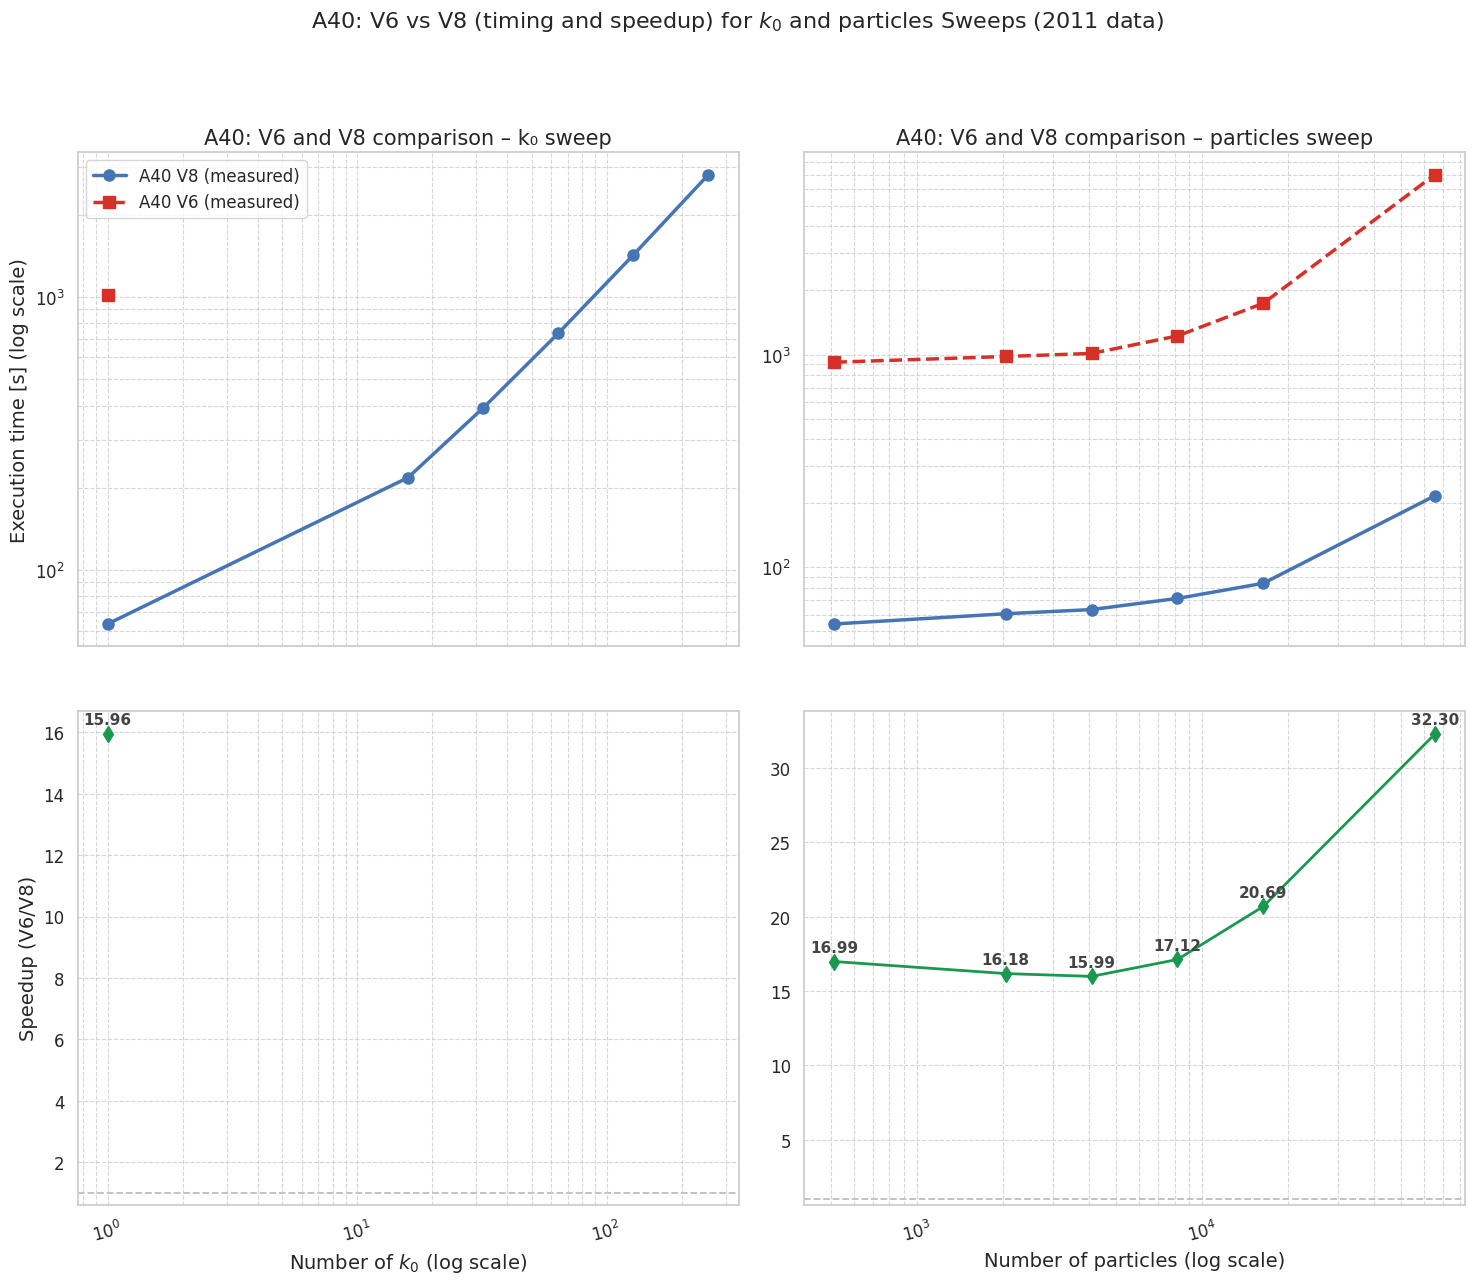

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
import os



# --- Data Loading and Filtering ---
# Filter for 2011 dates only
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
df = df[df['date'].dt.year == 2011]

# Focus: device = 'A40', test in ['k0', 'part']
df = df[(df['device'] == 'A40') & (df['test'].isin(['k0', 'part']))]
df['val'] = pd.to_numeric(df['val'], errors='coerce')
df['exetime'] = pd.to_numeric(df['exetime'], errors='coerce')
df = df.dropna(subset=['val', 'exetime', 'version'])

print(df[(df['version'] == 'V6') & (df['test'] == 'k0')])


# Aggregate mean execution time per group
summary = df.groupby(['test', 'version', 'val']).agg(
    mean_exetime=('exetime', 'mean')
).reset_index()

# --- Prepare Data for Plotting & Speedup Calculation ---

def get_measured_and_speedup(test_label):
    v6_data = summary[(summary['test'] == test_label) & (summary['version'] == 'V6')]
    v8_data = summary[(summary['test'] == test_label) & (summary['version'] == 'V8')]
    # Merge on val for speedup calculation
    speedup = None
    if not v6_data.empty and not v8_data.empty:
        merged = pd.merge(v6_data, v8_data, on='val', suffixes=('_v6', '_v8'))
        merged['speedup_v8_vs_v6'] = merged['mean_exetime_v6'] / merged['mean_exetime_v8']
        speedup = merged[['val', 'speedup_v8_vs_v6']]
    return v6_data, v8_data, speedup

# --- Plotting ---

sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.25)
fig, axes = plt.subplots(2, 2, figsize=(15, 13), gridspec_kw={'height_ratios': [2, 2]}, sharex='col')

test_configs = [
    ('k0',      'Number of $k_0$ (log scale)',      'k₀ sweep'),
    ('part',    'Number of particles (log scale)', 'particles sweep')
]

for idx, (test_label, xlabel, subtitle) in enumerate(test_configs):
    # --- Top: Execution times ---
    ax = axes[0, idx]
    v6_data, v8_data, speedup = get_measured_and_speedup(test_label)
    
    # Plot V8 measured
    if v8_data is not None and not v8_data.empty:
        ax.plot(
            v8_data['val'], v8_data['mean_exetime'],
            label='A40 V8 (measured)',
            marker='o', color='#4575b4', linestyle='-', linewidth=2.5, markersize=8
        )
    # Plot V6 measured
    if v6_data is not None and not v6_data.empty:
        ax.plot(
            v6_data['val'], v6_data['mean_exetime'],
            label='A40 V6 (measured)',
            marker='s', color='#d73027', linestyle='--', linewidth=2.5, markersize=8
        )
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel('')
    if idx == 0:
        ax.set_ylabel('Execution time [s] (log scale)', fontsize=14)
    else:
        ax.set_ylabel('')
    ax.set_title(f'A40: V6 and V8 comparison – {subtitle}', fontsize=15)
    ax.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.8)
    ax.tick_params(axis='both', which='major', labelsize=12)
    plt.setp(ax.get_xticklabels(), visible=False)
    if idx == 0:
        ax.legend(loc='upper left', fontsize=12, frameon=True)

    # --- Bottom: Speedup ---
    ax_speed = axes[1, idx]
    if speedup is not None and not speedup.empty:
        ax_speed.plot(
            speedup['val'], speedup['speedup_v8_vs_v6'],
            marker='d', color='#1a9850', linestyle='-', linewidth=2, markersize=8, label='V6/V8 speedup'
        )
        for x, y in zip(speedup['val'], speedup['speedup_v8_vs_v6']):
            ax_speed.annotate(f"{y:.2f}", (x, y),
                              textcoords="offset points", xytext=(0, 7), ha='center',
                              fontsize=11, color='#444', fontweight='bold', clip_on=True)
        ax_speed.axhline(1, color='#bdbdbd', linestyle='--', linewidth=1.3, zorder=0)
    else:
        ax_speed.text(0.5, 0.5, "No speedup data available", ha='center', va='center', fontsize=14, color='gray', transform=ax_speed.transAxes)
    ax_speed.set_xscale('log')
    ax_speed.set_xlabel(xlabel, fontsize=14)
    if idx == 0:
        ax_speed.set_ylabel('Speedup (V6/V8)', fontsize=14)
    else:
        ax_speed.set_ylabel('')
    ax_speed.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.8)
    ax_speed.tick_params(axis='both', which='major', labelsize=12)
    ax_speed.set_ylim(bottom=0.6)
    plt.setp(ax_speed.get_xticklabels(), rotation=15)

fig.suptitle(
    "A40: V6 vs V8 (timing and speedup) for $k_0$ and particles Sweeps (2011 data)",
    fontsize=16,
    y=1.03
)

fig.tight_layout(rect=[0, 0.05, 1, 0.98])
plt.subplots_adjust(bottom=0.11, top=0.92, hspace=0.13)

output_dir = "./output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plt.savefig("{}/A40_k0_part_v6v8_comparison_speedup_2011.png".format(output_dir), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
print(df[(df['version'] == 'V6') & (df['test'] == 'k0')])


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
import os

# Filter by date: only 2011 values
df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
df = df[df['date'].dt.year == 2011]

# Filter: only v8
df = df[df['version'] == 'V8']

# Filter for relevant test types only
df = df[df['test'].isin(['k0', 'part'])]
df['val'] = pd.to_numeric(df['val'], errors='coerce')
df['exetime'] = pd.to_numeric(df['exetime'], errors='coerce')
df = df.dropna(subset=['val', 'exetime', 'device', 'test', 'version'])

# Compute mean execution time per group
summary = df.groupby(['test', 'device', 'version', 'val']).agg(
    mean_exetime=('exetime', 'mean')
).reset_index()

# Set up the plot style
sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.25)

# Prepare unique lines for device+version
devices = sorted(summary['device'].unique())
versions = sorted(summary['version'].unique())
palette = sns.color_palette("tab10", n_colors=len(devices))
color_map = {dev: palette[i % len(palette)] for i, dev in enumerate(devices)}
linestyles = ['-', '--', '-.', ':']
linestyle_map = {ver: linestyles[i % len(linestyles)] for i, ver in enumerate(versions)}
markers = ['o', 's', '^', 'D', 'P', 'X', 'v', '*']
marker_map = {dev: markers[i % len(markers)] for i, dev in enumerate(devices)}

# Create subplots for each test type
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=True)

# Store handles and labels for legend
line_handles = []
line_labels = []

test_labels = {
    'k0': ('k₀ sweep', 'Number of $k_0$ (log scale)'),
    'part': ('particles sweep', 'Number of particles (log scale)')
}

for idx, test in enumerate(['k0', 'part']):
    ax = axes[idx]
    title, xlabel = test_labels[test]
    test_data = summary[summary['test'] == test]
    for device in devices:
        for version in versions:
            group = test_data[(test_data['device'] == device) & (test_data['version'] == version)].sort_values('val')
            if group.empty:
                continue
            label = f"{device} ({version})"
            (line,) = ax.plot(
                group['val'],
                group['mean_exetime'],
                label=label,
                marker=marker_map[device],
                color=color_map[device],
                linestyle=linestyle_map[version],
                linewidth=2,
                markersize=7,
                alpha=0.95
            )
            if idx == 0:
                line_handles.append(line)
                line_labels.append(label)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(xlabel, fontsize=14)
    if idx == 0:
        ax.set_ylabel('Execution time (s, log scale)', fontsize=14)
    ax.set_title(title, fontsize=15)
    ax.grid(True, which="both", ls="--", linewidth=0.6, alpha=0.7)
    ax.tick_params(axis='both', which='major', labelsize=12)
    plt.setp(ax.get_xticklabels(), rotation=15)

plt.tight_layout(rect=[0, 0.08, 1, 0.95])  # leave space for legend

# Unified legend below plots, showing device and version
fig.legend(
    handles=line_handles,
    labels=line_labels,
    title='GPU (COSMICA version)',
    loc='lower center',
    bbox_to_anchor=(0.5, -0.07),
    ncol=4,
    frameon=True,
    fontsize=12,
    title_fontsize=13
)

plt.subplots_adjust(top=0.88, bottom=0.20)

fig.suptitle(
    "Scaling of Execution Time by Device and Software Version for $k_0$ and number of particles (2011 data, log-log axes, mean values)",
    fontsize=16,
    y=1.02
)

output_dir = "./output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plt.savefig("{}/benchmark_scaling_2011.png".format(output_dir), bbox_inches='tight', dpi=300)
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO

# --- Data Loading and Filtering ---

df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
df = df[df['date'].dt.year == 2011]
df = df[df['device'].isin(['A40', 'A100'])]
df = df[df['test'].isin(['k0', 'part'])]
df['val'] = pd.to_numeric(df['val'], errors='coerce')
df['exetime'] = pd.to_numeric(df['exetime'], errors='coerce')
df = df.dropna(subset=['val', 'exetime', 'version'])

# Use only V8 if available for both devices, else intersection of available versions
common_versions = set(df[df['device'] == 'A40']['version']).intersection(df[df['device'] == 'A100']['version'])
if 'V8' in common_versions:
    df = df[df['version'] == 'V8']
else:
    df = df[df['version'].isin(common_versions)]

# Compute mean execution time per group
summary = df.groupby(['test', 'device', 'val']).agg(
    mean_exetime=('exetime', 'mean')
).reset_index()

# Prepare for plotting: merge A40/A100 for speedup
a40 = summary[summary['device'] == 'A40'].rename(columns={'mean_exetime': 'exetime_a40'})
a100 = summary[summary['device'] == 'A100'].rename(columns={'mean_exetime': 'exetime_a100'})
merged = pd.merge(a40, a100, on=['test', 'val'], suffixes=('_a40', '_a100'))
merged['speedup'] = merged['exetime_a40'] / merged['exetime_a100']

# --- Plotting ---

sns.set_theme(style="whitegrid")
sns.set_context("notebook", font_scale=1.35)
fig, axes = plt.subplots(2, 2, figsize=(15, 9), gridspec_kw={'height_ratios': [2.4, 1]}, sharex='col')

test_labels = {
    'k0': ('k₀ sweep', 'Number of $k_0$'),
    'part': ('particles sweep', 'Number of particles')
}
colors = {'A40': '#4575b4', 'A100': '#d73027'}

for col_idx, test in enumerate(['k0', 'part']):
    # --- Upper: Execution times ---
    ax_time = axes[0, col_idx]
    for device in ['A40', 'A100']:
        dat = summary[(summary['test'] == test) & (summary['device'] == device)].sort_values('val')
        ax_time.plot(
            dat['val'], dat['mean_exetime'],
            marker='o', linestyle='-', linewidth=2.5, markersize=10,
            color=colors[device], label=f"{device}"
        )
    ax_time.set_xscale('log')
    ax_time.set_yscale('log')
    ax_time.set_ylabel('Execution time [s]\n(log scale)', fontsize=14)
    ax_time.set_title(test_labels[test][0], fontsize=16, pad=10)
    ax_time.tick_params(axis='both', labelsize=12)
    ax_time.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.8)
    if col_idx == 0:
        ax_time.legend(loc='upper left', fontsize=13, frameon=True)
    else:
        ax_time.legend().remove()
    if col_idx == 0:
        ax_time.set_ylim(bottom=merged['exetime_a100'].min()*0.7, top=merged['exetime_a40'].max()*1.3)
    plt.setp(ax_time.get_xticklabels(), visible=False)

    # --- Lower: Speedup ---
    ax_speed = axes[1, col_idx]
    dat_speed = merged[merged['test'] == test].sort_values('val')
    ax_speed.plot(
        dat_speed['val'], dat_speed['speedup'],
        marker='s', linestyle='-', linewidth=2.5, markersize=8,
        color='#1a9850', label='Speedup (A40/A100)'
    )
    for x, y in zip(dat_speed['val'], dat_speed['speedup']):
        ax_speed.annotate(f"{y:.1f}", (x, y),
            textcoords="offset points", xytext=(0, 7), ha='center',
            fontsize=11, color='#444', fontweight='bold', clip_on=True)
    ax_speed.axhline(1, color='#bdbdbd', linestyle='--', linewidth=1.3, zorder=0)
    ax_speed.set_xscale('log')
    ax_speed.set_ylabel('Speedup\n(A40/A100)', fontsize=14)
    ax_speed.set_xlabel(test_labels[test][1] + ' (log scale)', fontsize=14)
    ax_speed.tick_params(axis='both', labelsize=12)
    ax_speed.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.8)
    ax_speed.set_ylim(bottom=0.6, top=max(dat_speed['speedup'].max()*1.16, 2.4))

fig.suptitle(
    "A100 vs A40: Timing and Speedup for $k_0$ and particles Sweeps (2011, V8)",
    fontsize=18, y=1.03
)
fig.tight_layout(rect=[0, 0.06, 1, 0.98])
plt.subplots_adjust(hspace=0.07, bottom=0.11, top=0.91)

output_dir = "./output"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
plt.savefig("{}/A40_A100_lines_and_speedup.png".format(output_dir), dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from io import StringIO
import os

def plot_device_pair_speedup(df, device1, device2, output_dir="./output"):
    # Only these devices, both test types, only 2011, only V8 if available for both
    df_pair = df[df['device'].isin([device1, device2]) & df['test'].isin(['k0', 'part'])]
    common_versions = set(df_pair[df_pair['device'] == device1]['version']).intersection(
        df_pair[df_pair['device'] == device2]['version']
    )
    if 'V8' in common_versions:
        df_pair = df_pair[df_pair['version'] == 'V8']
    else:
        df_pair = df_pair[df_pair['version'].isin(common_versions)]

    # Group for mean execution time
    summary = df_pair.groupby(['test', 'device', 'val']).agg(
        mean_exetime=('exetime', 'mean')
    ).reset_index()

    # Always use mean_exetime for plotting, don't try to use 'exetime_{device}' for summary
    dev1 = summary[summary['device'] == device1][['test', 'val', 'mean_exetime']].rename(columns={'mean_exetime': 'exetime_dev1'})
    dev2 = summary[summary['device'] == device2][['test', 'val', 'mean_exetime']].rename(columns={'mean_exetime': 'exetime_dev2'})
    merged = pd.merge(dev1, dev2, on=['test', 'val'])
    merged['speedup'] = merged['exetime_dev1'] / merged['exetime_dev2']

    sns.set_theme(style="whitegrid")
    sns.set_context("notebook", font_scale=1.35)
    fig, axes = plt.subplots(2, 2, figsize=(15, 9), gridspec_kw={'height_ratios': [2.4, 1]}, sharex='col')

    test_labels = {
        'k0': ('k₀ sweep', 'Number of $k_0$'),
        'part': ('particles sweep', 'Number of particles')
    }
    color_map = {device1: '#4575b4', device2: '#d73027'}

    for col_idx, test in enumerate(['k0', 'part']):
        # --- Upper: Execution times ---
        ax_time = axes[0, col_idx]
        for dev, col in zip([device1, device2], ['exetime_dev1', 'exetime_dev2']):
            dat = merged[merged['test'] == test][['val', col]].sort_values('val')
            ax_time.plot(
                dat['val'], dat[col],
                marker='o', linestyle='-', linewidth=2.5, markersize=10,
                color=color_map.get(dev, None), label=f"{dev}"
            )
        ax_time.set_xscale('log')
        ax_time.set_yscale('log')
        ax_time.set_ylabel('Execution time [s]\n(log scale)', fontsize=14)
        ax_time.set_title(test_labels[test][0], fontsize=16, pad=10)
        ax_time.tick_params(axis='both', labelsize=12)
        ax_time.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.8)
        if col_idx == 0:
            ax_time.legend(loc='upper left', fontsize=13, frameon=True)
        else:
            ax_time.legend().remove()
        plt.setp(ax_time.get_xticklabels(), visible=False)

        # --- Lower: Speedup ---
        ax_speed = axes[1, col_idx]
        dat_speed = merged[merged['test'] == test].sort_values('val')
        ax_speed.plot(
            dat_speed['val'], dat_speed['speedup'],
            marker='s', linestyle='-', linewidth=2.5, markersize=8,
            color='#1a9850', label=f'Speedup ({device1}/{device2})'
        )
        for x, y in zip(dat_speed['val'], dat_speed['speedup']):
            ax_speed.annotate(f"{y:.1f}", (x, y),
                textcoords="offset points", xytext=(0, 7), ha='center',
                fontsize=11, color='#444', fontweight='bold', clip_on=True)
        ax_speed.axhline(1, color='#bdbdbd', linestyle='--', linewidth=1.3, zorder=0)
        ax_speed.set_xscale('log')
        ax_speed.set_ylabel(f'Speedup\n({device1}/{device2})', fontsize=14)
        ax_speed.set_xlabel(test_labels[test][1] + ' (log scale)', fontsize=14)
        ax_speed.tick_params(axis='both', labelsize=12)
        ax_speed.grid(True, which="both", ls="--", linewidth=0.8, alpha=0.8)
        ax_speed.set_ylim(bottom=0.2, top=max(dat_speed['speedup'].max()*1.16, 2.4))
        plt.setp(ax_speed.get_xticklabels(), rotation=15)

    fig.suptitle(
        f"{device1} vs {device2}: Timing and Speedup for $k_0$ and particles Sweeps (2011, V8)",
        fontsize=18, y=1.03
    )
    fig.tight_layout(rect=[0, 0.06, 1, 0.98])
    plt.subplots_adjust(hspace=0.07, bottom=0.11, top=0.91)

    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    outname = f"{output_dir}/{device1}_{device2}_lines_and_speedup.png"
    plt.savefig(outname, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Saved {outname}")

# --- MAIN ---

df['date'] = pd.to_datetime(df['date'], format='%Y%m%d', errors='coerce')
df = df[df['date'].dt.year == 2011]
df['val'] = pd.to_numeric(df['val'], errors='coerce')
df['exetime'] = pd.to_numeric(df['exetime'], errors='coerce')
df = df.dropna(subset=['val', 'exetime', 'version'])

plot_device_pair_speedup(df, "A100", "A30")
plot_device_pair_speedup(df, "A40", "RTX3090")
plot_device_pair_speedup(df, "A40", "A100")